# Model with conditional interaction

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~5 s
- Description: Regional effects (PDP, ALE, RHALE) on a model with a
  conditional interaction: every method must find the split on $x_2$ at 0 and
  recover the per-region closed forms, tested against `effector.benchmarks`.
- 📄 The whole notebook in one page: [PDP report](https://xai-effector.github.io/static/reports/05_conditional_interaction_independent_uniform_regional_pdp.html)

In this example, we show regional effects of a model with conditional interactions using PDP, ALE, and RHALE.
In particular, we:

1. show how to use `effector` to estimate the regional effects using PDP, ALE, and RHALE
2. provide the analytical formulas for the regional effects
3. test that (1) and (2) match

We will use the following model: 

$$ 
f(x_1, x_2, x_3) = -x_1^2 \mathbb{1}_{x_2 <0} + x_1^2 \mathbb{1}_{x_2 \geq 0} + e^{x_3} 
$$

where the features $x_1, x_2, x_3$ are independent and uniformly distributed in the interval $[-1, 1]$.


The model has an _interaction_ between $x_1$ and $x_2$ caused by the terms: 
$f_{1,2}(x_1, x_2) = -x_1^2 \mathbb{1}_{x_2 <0} + x_1^2 \mathbb{1}_{x_2 \geq 0}$.
This means that the effect of $x_1$ on the output $y$ depends on the value of $x_2$ and vice versa.
Therefore, there is no golden standard on how to split the effect of $f_{1,2}$ to two parts, one that corresponds to $x_1$ and one to $x_2$.
Each global effect method has a different strategy to handle this issue.
Below we will see how PDP, ALE, and RHALE handle this interaction.

In contrast, $x_3$ does not interact with any other feature, so its effect can be easily computed as $e^{x_3}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import effector

np.random.seed(21)

bench = effector.benchmarks.ConditionalInteractionUniform()
model = bench.model
dataset = bench.dataset
x = bench.generate_data(1_000)

## Why regional effects?

As shown in the [global-effects notebook](./05_conditional_interaction_independent_uniform_global.md),
the global effect of $x_1$ is **zero with high heterogeneity**: for instances
with $x_2 < 0$ the local effect is $-x_1^2$ and for $x_2 \geq 0$ it is $+x_1^2$,
so the average washes out.

Regional effect methods ask the natural follow-up: *is there a split of the
input space that makes the local effects agree within each subregion?* Here the
answer is known by construction — splitting on $x_2 = 0$ yields two regions
where the effect of $x_1$ is deterministic:

$$
\text{effect}(x_1 \mid x_2 < 0) = -x_1^2, \qquad
\text{effect}(x_1 \mid x_2 \geq 0) = +x_1^2,
$$

each with **zero** heterogeneity. After zero-integral centering over
$x_1 \in [-1, 1]$ (the mean of $x_1^2$ is $1/3$), the closed forms are
$\mp x_1^2 \pm 1/3$. Every regional method below must recover: the split
feature ($x_2$), the split position ($\approx 0$), and the per-region curves.

## New-API: importance and one-click explain

Before drilling into the regional splits, the new API offers two shortcuts on
top of the global effect. `importances()` ranks features by the **dispersion of
their mean effect** (the μ-twin of heterogeneity): here $x_3$ (the monotone
$e^{x_3}$) carries a large mean effect, while $x_1$'s mean effect washes out to
$\approx 0$ (its signal lives entirely in the *heterogeneity* that the regional
split below explains). `effector.explain(...)` runs the whole pipeline once and
returns a serializable `Report`.

In [2]:
# per-feature importance = dispersion of the mean effect (mu-twin of heterogeneity)
fx = effector.PDP(
    data=x, model=model.predict,
    axis_limits=dataset.axis_limits,
    nof_instances="all",
)
print("importances:", np.round(fx.importances(), 3))

# one-click auto-explanation -> Report (serializable; self-contained HTML)
report = effector.explain(x, model.predict, method="pdp", nof_instances="all")
report.show()

# the whole notebook, in one page: the report published with this example
from pathlib import Path
_out = Path("reports") / "05_conditional_interaction_independent_uniform_regional"
_out.mkdir(parents=True, exist_ok=True)
report.to_html(_out / "report_pdp.html")


importances: [0.007 0.326 0.668]
[effector] global effects   (GAM)  -> 86.7% of the model's variance
           regional effects (CALM) -> 99.8%

  ════════════════════════════════════════════════════════════════════════
  PDP report  ·  target: y
  ════════════════════════════════════════════════════════════════════════

  DATA & MODEL
  ────────────────────────────────────────────────────────────────────────
    instances     1,000
    features      3  ·  3 continuous
    model output  mean 1.17 · std 0.803 · range [-0.546, 3.38]

  EXPLAINED VARIANCE
  ────────────────────────────────────────────────────────────────────────
    step         split on                 solo     ΔR²      R²       heter
    ──────────────────────────────────────────────────────────────────────
    GAM          (all features global)       —       —   86.7%           —
  + x_0          x_1                    +13.1%  +13.1%   99.8% 0.29 → 0.00
    ─────────────────────────────────────────────────────────────

/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


## Regional PDP

### Effector

In [3]:
pdp = effector.PDP(
    data=x, model=model.predict,
    axis_limits=dataset.axis_limits,
    nof_instances="all",
)
pdp.fit("all", centering=True)
finder = effector.space_partitioning.Best()
partitions_pdp = {feat: pdp.find_regions(feat, finder=finder) for feat in range(3)}
partitions_pdp[0].show()



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x_0 🔹 [id: 0 | heter: 0.29 | inst: 1000 | w: 1.00]
    x_1 < 0.00 🔹 [id: 1 | heter: 0.00 | inst: 488 | w: 0.49]
    x_1 ≥ 0.00 🔹 [id: 2 | heter: 0.00 | inst: 512 | w: 0.51]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.29
    Level 1🔹heter: 0.00 | 🔻0.29 (100.00%)




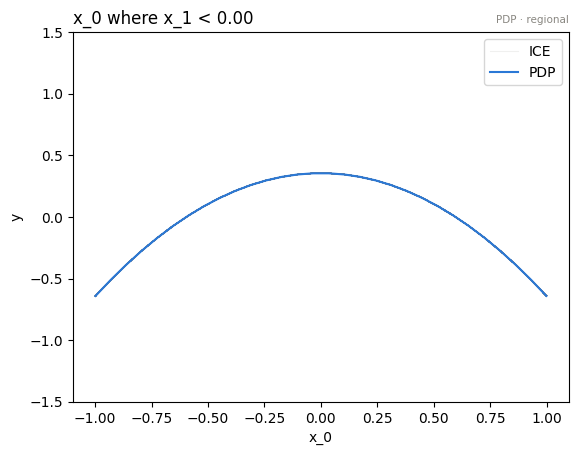

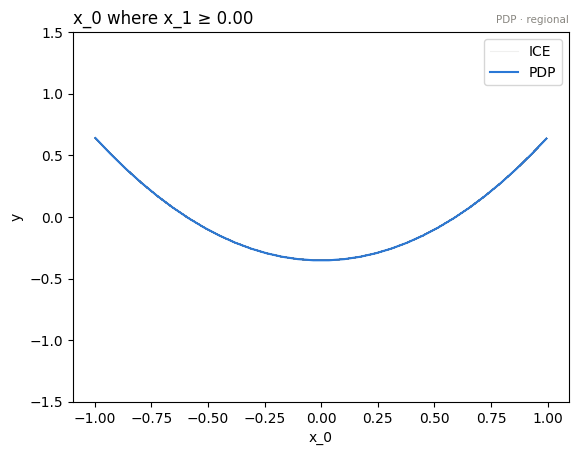

In [4]:
for region_idx in [1, 2]:
    partitions_pdp[0].plot(region_idx, heterogeneity="ice", centering=True, y_limits=[-1.5, 1.5])

### Tests

In [5]:
# the same closed forms the test suite asserts against
# (tests/test_functional_conditional_interaction.py::TestRegionalEffects)
xx = np.linspace(-1, 1, 100)


def check_regions(partition):
    children = [r for r in partition if r.level == 1]
    assert len(children) == 2
    for r in children:
        # the split must be on x2 at ~0 (the region's Rule is its identity)
        assert r.rule.features == (bench.regional_split_feature,)
        interval = r.rule[bench.regional_split_feature]
        pos = interval.hi if np.isfinite(interval.hi) else interval.lo
        assert abs(pos - bench.regional_split_position) <= 0.15
        # inside each region: -+x1^2 (centered), with ~zero heterogeneity;
        # x < t (upper-bounded interval) is the left child, x >= t the right
        side = "left" if not np.isfinite(interval.lo) else "right"
        y = partition.eval(r.idx, xx, centering=True)
        heter = partition.eval_heter(r.idx, xx)
        np.testing.assert_allclose(y, bench.regional_effect_gt(side, xx), atol=1e-1)
        np.testing.assert_allclose(heter, np.zeros_like(xx), atol=1e-1)


check_regions(partitions_pdp[0])

## Regional ALE

### Effector

In [6]:
ale = effector.ALE(
    data=x, model=model.predict,
    axis_limits=dataset.axis_limits,
    nof_instances="all",
)
ale.fit("all", centering=True)
finder = effector.space_partitioning.Best()
partitions_ale = {feat: ale.find_regions(feat, finder=finder) for feat in range(3)}
partitions_ale[0].show()



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x_0 🔹 [id: 0 | heter: 0.66 | inst: 1000 | w: 1.00]
    x_1 < 0.00 🔹 [id: 1 | heter: 0.00 | inst: 488 | w: 0.49]
    x_1 ≥ 0.00 🔹 [id: 2 | heter: 0.00 | inst: 512 | w: 0.51]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.66
    Level 1🔹heter: 0.00 | 🔻0.66 (100.00%)




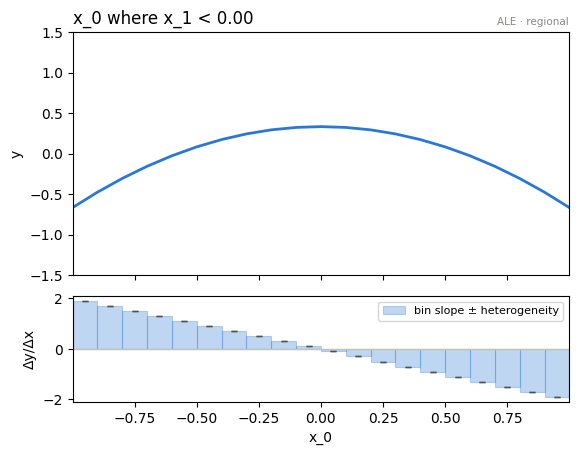

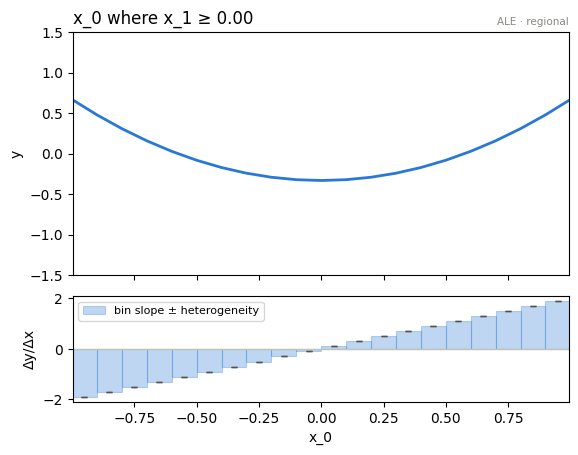

In [7]:
for region_idx in [1, 2]:
    partitions_ale[0].plot(region_idx, centering=True, y_limits=[-1.5, 1.5])

### Tests

In [8]:
check_regions(partitions_ale[0])

## Regional RHALE

### Effector

In [9]:
rhale = effector.RHALE(
    data=x, model=model.predict, model_jac=model.jacobian,
    axis_limits=dataset.axis_limits,
    nof_instances="all",
)
rhale.fit("all", centering=True)
finder = effector.space_partitioning.Best()
partitions_rhale = {feat: rhale.find_regions(feat, finder=finder) for feat in range(3)}
partitions_rhale[0].show()



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x_0 🔹 [id: 0 | heter: 0.66 | inst: 1000 | w: 1.00]
    x_1 < 0.00 🔹 [id: 1 | heter: 0.03 | inst: 488 | w: 0.49]
    x_1 ≥ 0.00 🔹 [id: 2 | heter: 0.03 | inst: 512 | w: 0.51]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.66
    Level 1🔹heter: 0.03 | 🔻0.63 (95.01%)




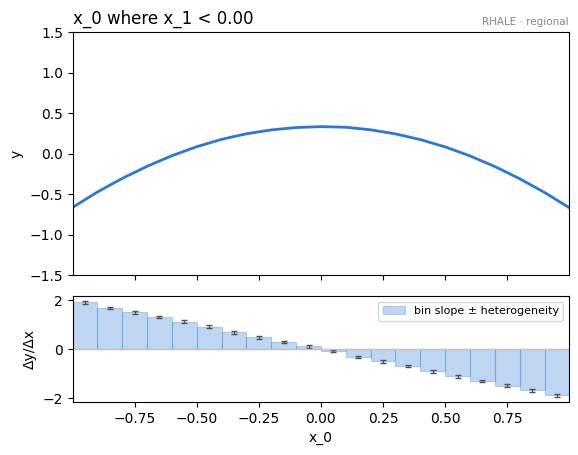

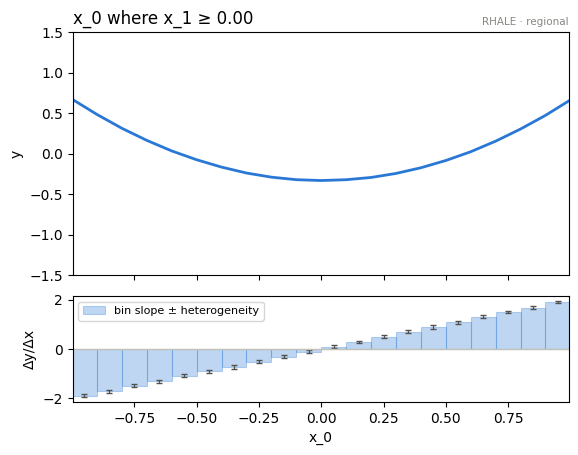

In [10]:
for region_idx in [1, 2]:
    partitions_rhale[0].plot(region_idx, centering=True, y_limits=[-1.5, 1.5])

### Tests

In [11]:
check_regions(partitions_rhale[0])

## Conclusions

All three regional methods recover the ground truth: they split on $x_2$ at
$\approx 0$ and, inside each region, report the deterministic effect
$\mp x_1^2$ (centered) with heterogeneity dropping from $\sim 0.1$ at the root
to $\approx 0$ — the model's conditional interaction is *fully explained* by a
single split. This is the ideal-case benchmark for regional methods: when a
crisp subspace structure exists, the methods must find exactly it.

## Cross-method sanity check

The one-liner `effector.explain` with every engine this notebook's model
supports. Everything must run end to end; the closing table puts the reads
side by side. Where methods disagree — ranking, accepted splits, R² — that is
a property of the data/model worth a closer look, not an error.


In [12]:
from pathlib import Path
_out = Path("reports") / "05_conditional_interaction_independent_uniform_regional"
_out.mkdir(parents=True, exist_ok=True)

# === cross-method sweep: effector.explain on every applicable engine ======
sweep_reports = {}
for _m in ["pdp", "derpdp", "ale", "rhale", "shapdp"]:
    _kw = {"nof_instances": 300} if _m == "shapdp" else {}
    print(f"--- {_m} " + "-" * 50)
    sweep_reports[_m] = effector.explain(
        x, model.predict, model.jacobian, method=_m, **_kw
    )
    if _m != "pdp":  # the published report is the narrated one above
        sweep_reports[_m].to_html(_out / f"report_{_m}.html")

print()
print(f"{'method':<8} {'ranking (plotted)':<44} {'GAM R2':>8} {'final R2':>9}  splits")
for _m, _r in sweep_reports.items():
    _rank = " > ".join(fr.name for fr in _r.features)
    _ev = _r.explained_variance
    if _ev:
        _sp = "; ".join(f"{s['name']} on {s['on']}" for s in _ev["stages"]) or "none"
        print(f"{_m:<8} {_rank:<44} {_ev['gam_r2']:>7.1%} {_ev['regional_r2']:>8.1%}  {_sp}")
    else:
        print(f"{_m:<8} {_rank:<44} {'-':>7} {'-':>8}  (derivative scale: no variance ledger)")

print(f"\nreports stored in {_out}/")


--- pdp --------------------------------------------------
[effector] global effects   (GAM)  -> 86.7% of the model's variance
           regional effects (CALM) -> 99.8%
--- derpdp --------------------------------------------------


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- ale --------------------------------------------------
[effector] global effects   (GAM)  -> 85.3% of the model's variance
           regional effects (CALM) -> 98.8%


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- rhale --------------------------------------------------
[effector] global effects   (GAM)  -> 70.0% of the model's variance
           regional effects (CALM) -> 100.0%


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- shapdp --------------------------------------------------


[effector] global effects   (GAM)  -> 87.3% of the model's variance
           regional effects (CALM) -> 96.6%


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



method   ranking (plotted)                              GAM R2  final R2  splits
pdp      x_2 > x_1 > x_0                                86.7%    99.8%  x_0 on x_1
derpdp   x_2                                                -        -  (derivative scale: no variance ledger)
ale      x_2 > x_1 > x_0                                85.3%    98.8%  x_0 on x_1
rhale    x_2 > x_0                                      70.0%   100.0%  x_0 on x_1
shapdp   x_2 > x_1 > x_0                                87.3%    96.6%  x_0 on x_1

reports stored in reports/05_conditional_interaction_independent_uniform_regional/
